# DTLZ1 Results

In [ ]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz1_front_random
from deap import benchmarks

# 1. Parâmetros
K = 5
NPOP = 800
NGEN = 600
NOBJ = 4 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz1_segura = partial(benchmarks.dtlz1, obj=NOBJ)
toolbox = build_toolbox(func_dtlz1_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz1_front_random(NOBJ, 1000)
    reset = 40
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...


[1.0, 1.0, 0.0, 0.49999991016276485, 0.5002229735540381, 0.49997512515309955, 0.498992097494597, 0.5970190010867725]
[1.0, 1.0, 0.0, 0.49999991016276485, 0.5002229735540381, 0.49997512515309955, 0.498992097494597, 0.5970190010867725]
[0.0, 0.8891193272141117, 0.9959281325782259, 0.4999999469134537, 0.5000039833289366, 0.49996288148700196, 0.5000008713422595, 0.5000001057106919]
[1.0, 1.0, 1.0, 0.49999867826593697, 0.4999634065632179, 0.49996102486507826, 0.4979081674010214, 0.4990212545146033]
[1.0, 0.0, 0.9389521400353241, 0.49999995800806024, 0.500000312170731, 0.49999961156580297, 0.5000017290496613, 0.49999895710154224]
[0.9998195561984105, 0.9991364129683167, 5.237119182953387e-06, 0.49999996997497426, 0.5000002460413056, 0.5021977940322547, 0.5000063743624623, 0.6000867610372889]
[0.7755859763888634, 0.9997436413892887, 0.9821284614205347, 0.49999994969009387, 0.5000001871336238, 0.500000351776553, 0.4979627070019591, 0.4999543051450365]
[0.5786334341760558, 1.0, 0.87624413215061

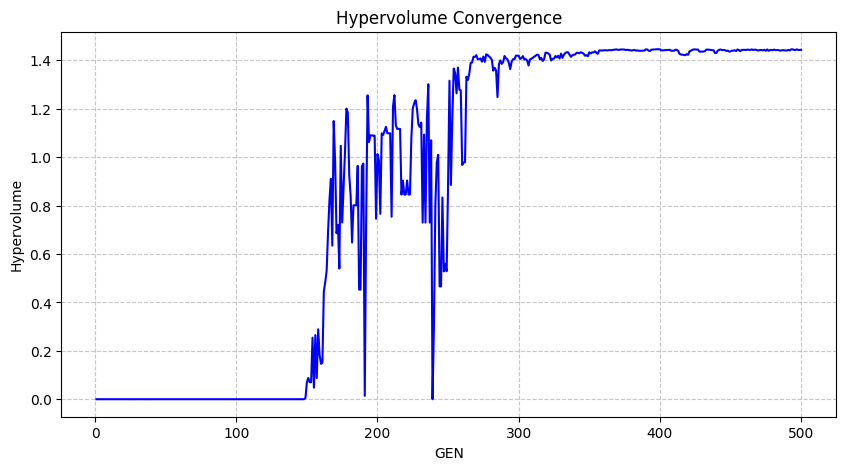

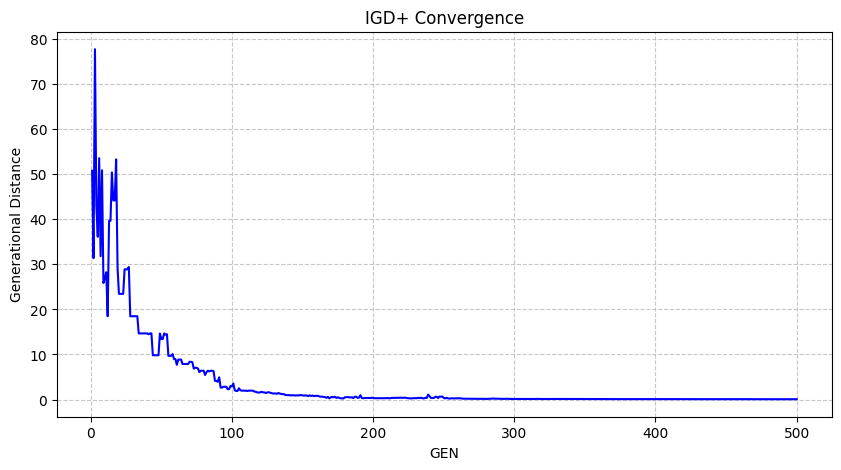

In [ ]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
    print(ind)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
\
# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()